# Telco Customer Churn — Exploratory Data Analysis

## Objective

Explore customer behavior and identify factors associated with customer churn.

The analysis focuses on customer demographics, services, contract type,
tenure, and billing information.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "telco_customer_churn_clean.csv"
)

df = pd.read_csv(DATA_PATH)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
df.shape

(7043, 20)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [7]:
df.shape

(7043, 20)

In [8]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index",
) * 100

contract_churn

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


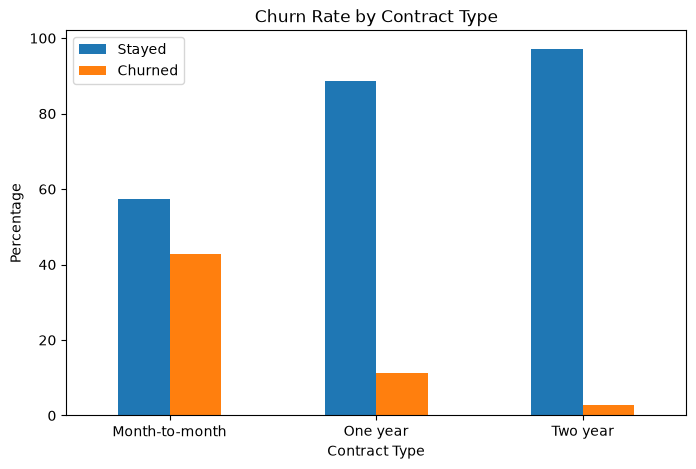

In [9]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])
plt.show()

In [10]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, float("inf")],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49+ months",
    ],
)

In [11]:
tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index",
) * 100

tenure_churn

Churn,0,1
tenure_group,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49+ months,90.486824,9.513176


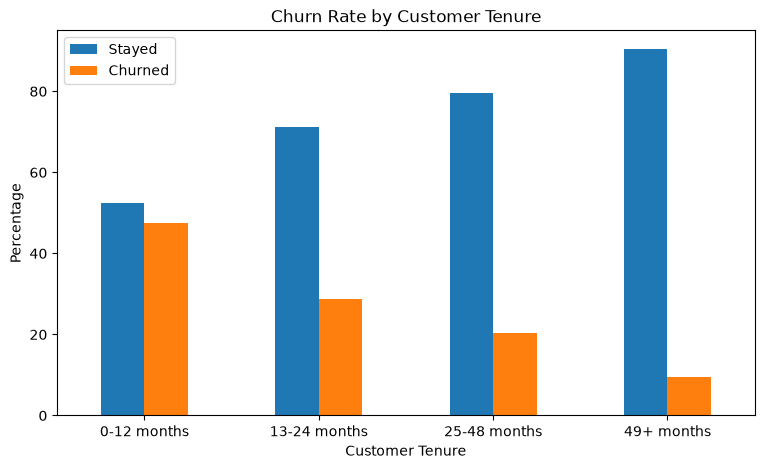

In [12]:
tenure_churn.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])
plt.show()

### Key Insight — Customer Tenure

Customer churn is substantially higher among newer customers and decreases
as customer tenure increases.

The highest churn levels are observed among customers with less than two
years of tenure, while customers with 49+ months show a much lower churn rate.

This suggests that early-stage customer retention and onboarding may be
critical areas for reducing churn.

In [13]:
df["monthly_charge_group"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High",
    ],
)

In [14]:
charge_churn = pd.crosstab(
    df["monthly_charge_group"],
    df["Churn"],
    normalize="index",
) * 100

charge_churn

Churn,0,1
monthly_charge_group,,
Low,88.762770,11.237230
Medium-Low,75.424689,24.575311
Medium-High,62.492886,37.507114
High,67.121729,32.878271


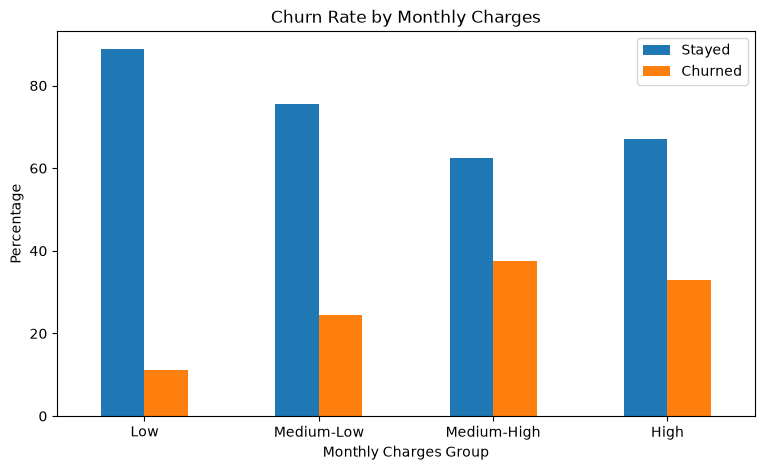

In [15]:
charge_churn.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charges Group")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])
plt.show()

### Key Insight — Monthly Charges

Customers with higher monthly charges generally show higher churn rates.

The churn rate increases from the lowest monthly-charge group to the
medium-high and high-charge groups.

This suggests that pricing level, perceived value, or the services associated
with higher charges may be relevant factors in customer retention.

This analysis shows an association, not a causal relationship.

In [16]:
tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index",
) * 100

tech_support_churn

Churn,0,1
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


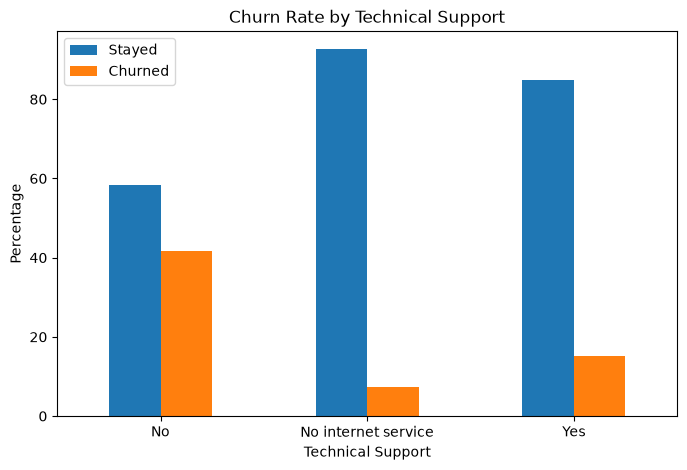

In [17]:
tech_support_churn.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])
plt.show()

In [18]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index",
) * 100

security_churn

Churn,0,1
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


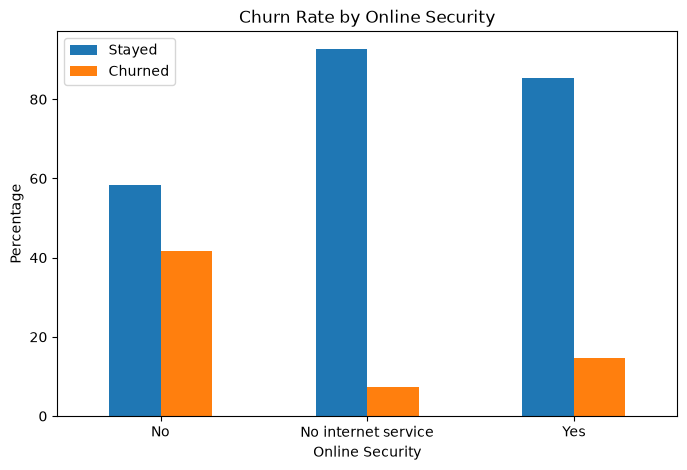

In [19]:
security_churn.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])
plt.show()

### Key Insight — Online Security

Customers without online security show a substantially higher churn rate
than customers with online security.

This suggests that online security is associated with customer retention
and may be relevant when designing customer retention strategies.

This analysis identifies an association and does not establish causation.